# Logistic Regression

## Concept

In Machine Learning, we often want to predict **categories instead of numbers**.

Examples:

Spam detection  
→ Spam / Not Spam

Medical diagnosis  
→ Disease / No Disease

Image classification  
→ Cat / Dog

This type of problem is called **Classification**.

Linear Regression predicts **continuous values**, but Logistic Regression predicts **probabilities of classes**.

Example:

P(Spam | Email) = 0.92

If probability > 0.5 → Spam  
If probability < 0.5 → Not Spam

Logistic Regression uses a function called the **Sigmoid Function** to convert any number into a probability between **0 and 1**.

So the pipeline becomes:

Input Features  
→ Linear Model  
→ Sigmoid Function  
→ Probability  
→ Class Prediction

# Math Behind Logistic Regression

First we compute a **linear combination** of the inputs.

z = w₁x₁ + w₂x₂ + ... + b

Where:

w = weights  
x = input features  
b = bias

But instead of predicting z directly, we apply the **Sigmoid Function**.

Sigmoid Function:

σ(z) = 1 / (1 + e^(-z))

This transforms the output into a value between **0 and 1**, which we interpret as probability.

Example:

σ(3) ≈ 0.95  
σ(-3) ≈ 0.05

Decision Rule:

If σ(z) ≥ 0.5 → Class 1  
If σ(z) < 0.5 → Class 0

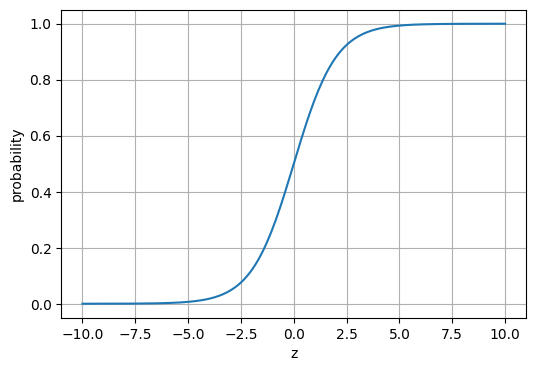

In [2]:
import numpy as np
import matplotlib.pyplot as plt


def sigmoid(z):
   return 1/(1+np.exp(-z))


z = np.linspace(-10, 10, 200)
y = sigmoid(z)

plt.figure(figsize=(6, 4))
plt.plot(z, y)
plt.xlabel("z")
plt.ylabel("probability")
plt.grid(True)
plt.show()

This graph shows how the Sigmoid function converts any number into probability.

In [3]:
import numpy as np

# simple dataset
X = np.array([1,2,3,4,5])
y = np.array([0,0,0,1,1])

w = 0
b = 0
lr = 0.1

def sigmoid(z):
    return 1/(1+np.exp(-z))

for epoch in range(1000):

    z = w*X + b
    pred = sigmoid(z)

    dw = np.mean((pred - y)*X)
    db = np.mean(pred - y)

    w -= lr*dw
    b -= lr*db

print("Trained Weight:",w)
print("Trained Bias:",b)

Trained Weight: 1.769045864973106
Trained Bias: -5.956350539118638


This is a minimal logistic regression implementation using gradient descent.

In [6]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

data = load_breast_cancer()

X_train,X_test,y_train,y_test = train_test_split(
    data.data,
    data.target,
    test_size=0.2,
    random_state=42
)

model = LogisticRegression(max_iter=10000)

model.fit(X_train,y_train)

accuracy = model.score(X_test,y_test)

print("Model Accuracy:",accuracy)

Model Accuracy: 0.956140350877193


This experiment applies logistic regression to a real medical dataset.

# Summary

Today we learned **Logistic Regression**, the most fundamental classification algorithm.

Key ideas:

1. Classification predicts categories.
2. Logistic Regression outputs probabilities.
3. The Sigmoid function converts numbers into probabilities.
4. Decision boundary is usually 0.5 probability.

Pipeline:

Features  
→ Linear Equation  
→ Sigmoid Function  
→ Probability  
→ Class Prediction

Advantages:

- Simple
- Interpretable
- Fast

Limitations:

- Only works well when data is linearly separable.